# 머신러닝 프로젝트

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 강의노트이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.

**권장 사항**

[(강의노트) 머신러닝 프로젝트](https://codingalzi.github.io/code-workout-ml/end2end-ml-project/)를 병행하여 읽을 것을 권장한다.

## 환경설정

This project requires Python 3.10 or above:

In [1]:
import sys

assert sys.version_info >= (3, 10)

It also requires Scikit-Learn ≥ 1.6.1:

In [2]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

Let's define the default font sizes, to plot pretty figures:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

**기본 라이브러리**

In [4]:
import numpy as np
import pandas as pd

## 머신러닝 모델 훈련용 데이터

### 데이터 기초 정보

1990년도에 시행된 미국 캘리포니아 주의 20,640개 구역별 주택 가격 데이터는
위 엑셀 파일 그림의 1번 행에 표시된 대로
경도, 위도, 주택 건물 중위연령, 총 방 수, 총 침실 수, 인구, 가구 수, 중위소득, 중위 주택가격, 해안 근접도
등 총 10개의 **특성**<font size='2'>feature</font>을 포함한다. 
참고로 통계 분야에서는 특성을 변수 또는 변인 등으로 부르지만 머신러닝 분야에서는 특성이라 부르는 게 일반적이다.

아래 그림은 원본 csv 파일의 일부 내용을 보여준다.

<div align="center">
    <img src="https://github.com/codingalzi/code-workout-ml/blob/master/images/ch02/housing-data.png?raw=true" width="700">
</div>

### 머신러닝 훈련 모델 선택 기준

구역별 중위 주택가격을 타깃으로 예측하는 시스템에 활용될
**회귀 모델**을 훈련시키고자 한다.
여기서 훈련시킬 모델의 특성은 다음과 같다.

* 지도학습: 구역별 중위 주택가격을 타깃, 즉
    최대한 정확하게 예측해야 하는 목표로 지정한다. 

* 회귀: 중위 주택가격, 즉 이산형 값이 아닌 연속형 값을 예측한다. 
    보다 세분화하면 다중 회귀이자 단변량 회귀 모델이다.
  * 다중 회귀<font size="2">multiple regression</font>: 구역별로 여러 특성을 주택 가격 예측에 사용
  * 단변량 회귀<font size="2">univariate regression</font>: 구역별로 한 종류의 값만 예측

* 배치 학습: 빠르게 변하는 데이터에 적응할 필요가 없으며, 데이터셋의 크기도 충분히 작기에
    데이터셋 전체를 대상으로 훈련을 진행한다.

### 데이터 구하기

캘리포니아 주택 가격 데이터는 매우 유명하여 많은 공개 저장소에서 다운로드할 수 있다.
여기서는 개인 깃허브 리포지토리에 압축파일로 저장한 파일을 다운로드해서 사용한다.

아래 코드의 `load_housing_data()` 함수는
지정된 깃허브 리포지토리에 tgz 형식의 압축 파일로 저장되어 있는
캘리포니아 주택 가격 데이터를 다운로드한 후에 
Pandas 데이터프레임으로 변환하여 반환한다.
최종적으로 `housing_full` 변수는 캘리포니아 주택 가격 데이터를 담고 있는 데이터프레임을 가리킨다.

**데이터셋 다운로드**

In [5]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

## 데이터셋 탐색

데이터 탐색은 훈련을 시작하기 전에 주어진 데이터셋의
다양한 특성을 대략적으로 살펴보는 과정이다.
데이터 시각화는 데이터 탐색을 위한 주요 기법 중의 하나이다.
먼저 데이터프레임의 메서드를 활용한 데이터 탐색을 알아본다.

### 데이터프레임 활용

In [6]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


### 범주형 대 수치형

**범주형 특성**

'해안 근접도'는 5개의 범주로 구분된다.
데이터프레임의 `valule_counts()` 메서드는 사용된 특성값과 각각의 특성값이 사용된 횟수를 확인해준다.

In [8]:
housing_full["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

각 특성값의 의미는 다음과 같다.

| 특성값 | 설명 |
| :--- | :--- |
| <1H OCEAN | 해안에서 1시간 이내 |
| INLAND | 내륙 |
| NEAR OCEAN | 해안 근처 |
| NEAR BAY | 샌프란시스코의 Bay Area 구역 |
| ISLAND | 섬  |

**수치형 특성**

범주형 특성과는 다르게 수치형 특성은 정수 또는 부동소수점으로 구성된 특성이며, 
평균값, 표준편차, 사분범위 등 수치형 특성들의 정보를 확인할 수 있다.
해안 근접도를 제외한 나머지 특성들 모두 수치형 특성이다.

In [9]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


수치형 특성별로 히스토그램을 통해 다음 정보를 얻을 수 있다.

- 각 특성마다 사용되는 단위와 스케일이 다르다. 1 단위부터 만 단위까지 다양하다.
- 일부 특성은 한쪽으로 치우쳐저 있다. 
    예를 들어 `total_rooms`, `total_bedrooms`, `population`, `households` 등의 특성값들이 오른쪽 꼬리를 길게 갖는다.
- 일부 특성은 값을 제한한 것으로 보인다. 
 예를 들어 `housing_median_age`, `median_house_value` 등의 특성값 상한값이 임의로 지정되어 잘린 것처럼 보인다.

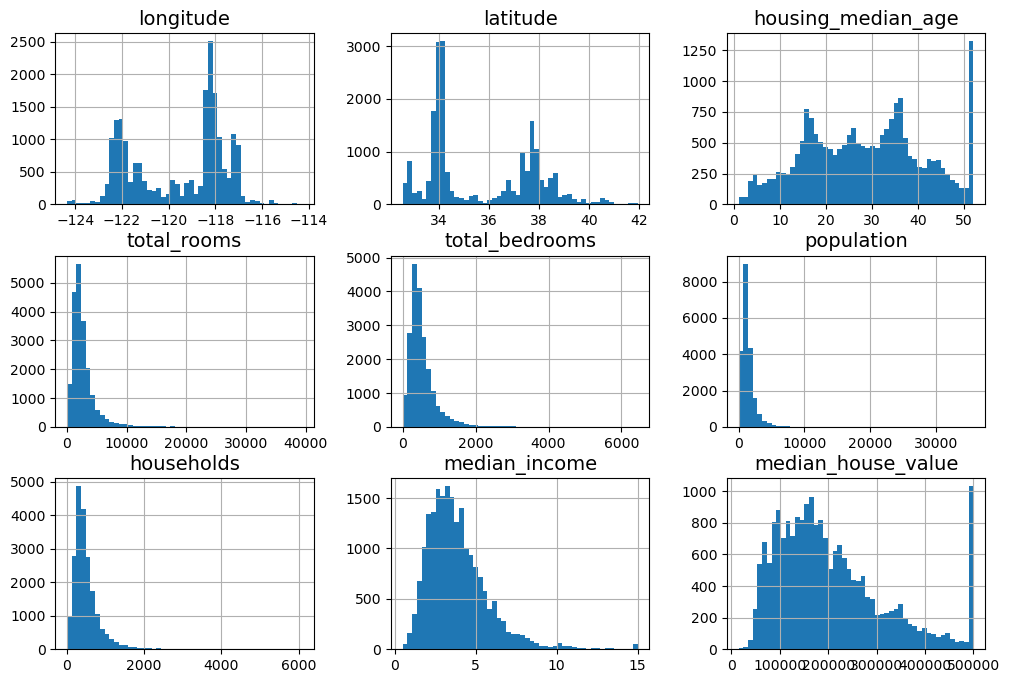

In [10]:
housing_full.hist(bins=50, figsize=(12, 8))

plt.show()

## 훈련셋과 테스트셋

모델 훈련을 시작하기 전에 전체 데이터셋을 보통 **훈련셋**<font size='2'>training set</font>과
**테스트셋**<font size='2'>test set</font>으로 나눈다.
테스트셋은 훈련 과정중에 전혀 사용되지 않으며 보통 전체 데이터셋의 최대 10~20% 정도로
선택하며, 전체 데이터셋의 크기에 따라 테스트셋의 크기가 너무 크지 않게 
비율을 적절히 조절한다.

- 훈련셋: 머신러닝 모델 훈련에 사용되는 데이터셋을 가리킨다.
    이후에 실제 모델 훈련을 시작하기 전에 다시 입력 데이터셋과 타깃셋으로 특성을 기준으로 쪼개진다.
- 테스트셋: 훈련을 마친 모델의 성능을 평가하기 위해 사용하는 데이터셋이다.
    훈련 과정에서는 어떤 형식으로든 절대로 활용하지 않는다.
    훈련될 모델을 이용하여 테스트되기 이전에 훈련세처럼 
    동일한 기준으로 입력 데이터셋과 타깃셋으로 나뉘어진다.

### 무작위 샘플링

전체 데이터에서 무작위로 샘플을 추출하는 방식이다.
데이터셋이 매우 크다면 모집단을 잘 대표할 수 있지만, 그렇지 않을 경우 샘플링 편향이 발생해 특정 특징을 가진 데이터가 과하게 많거나 적게 추출될 위험이 있다.

In [11]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

### 계층 샘플링

샘플링 편향을 최대한 방지하기 위해 중위소득을 기준으로 
계층 샘플링<font size='2'>stratified sampling</font>을 활용할 수 있다.
계층 샘플링을 층화표집으로 부르기도 한다.

먼저 구역별 중위소득 특성을 대상으로 히스토그램을 그려보면
대부분 구역의 중위소득이 1.5 ~ 6.0, 즉 15,000에서 60,000 달러 사이인 것을 알 수 있다.

<Axes: >

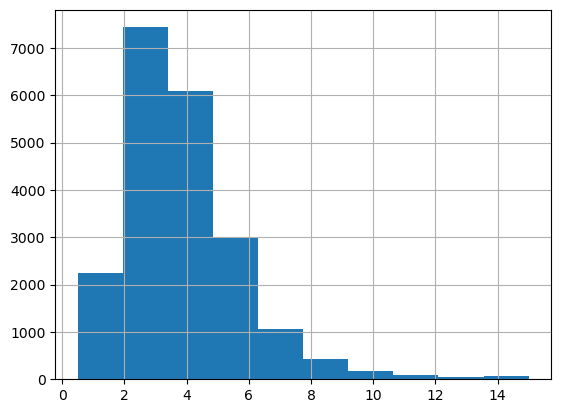

In [12]:
housing_full['median_income'].hist()

따라서 중위소득 구간을 아래처럼 5개로 구분한 다음에 계층 샘플링을 이용하여
훈련셋과 테스트셋을 구분하면 좋을 것 같아 보인다.

In [13]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                    labels=[1, 2, 3, 4, 5])

먼저 언급된 5 개의 구간으로 구분하는 `"income_cat"` 특성을 추가한다.
`pd.cut()` 함수는 특성과 구간 구분이 주어지면 각 구간에 해당하는 특성값들에 지정된 레이블을 할당하는
형식으로 새로운 특성값들을 만들어 낸다.

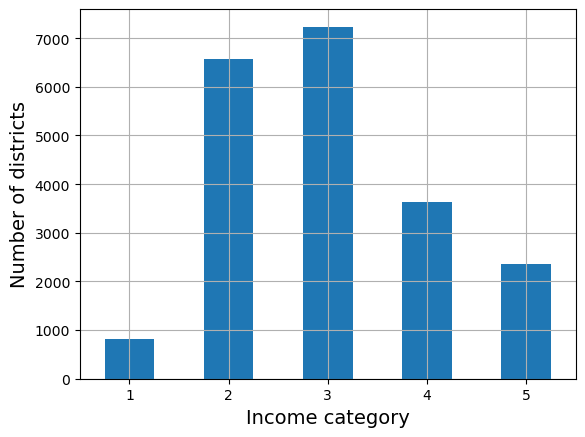

In [14]:
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")

plt.show()

이제 `"income_cat"` 특성에 사용된 값들의 분포 비율을 반영하면서 
훈련셋과 테스트셋을 8대 2로 나눈다.
사이킷런의 `train_test_split()` 함수는 데이터프레임에 속한 샘플을
지정된 비율로 두 개의 데이터프레임으로 나눌 때
계층 샘플링을 지원한다.

In [15]:
strat_train_set, strat_test_set = train_test_split(
    housing_full, 
    test_size=0.2,
    stratify=housing_full["income_cat"],            # 계층 샘플링을 위한 기준이 되는 열 지정
    random_state=42)

### 무작위 샘플링 대 계층 샘플링

계층 샘플링이 무작위 샘플링보다 계층별 샘플의 비율을 훨씬 잘 유지함을 아래 표가 확인해준다.
`Strat. Error %`와 `Rand. Error %`는 모집단에서의 계층별 빈도 기준 표본에서의 계층별 빈도의
변화율을 가리킨다.
계층 샘플링이 변화율이 무작위 샘플링의 변화율보다 작음에 주목한다.

In [16]:
# extra code – computes the data for Figure 2–10

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing_full),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()

compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] / 
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


**`income_cat` 특성 삭제**

해당 특성은 계층 샘플링을 위한 용도로만 사용되기에 더 이상 필요 없어서 
훈련셋과 테스트셋 모두에서 삭제한다.

In [17]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## 훈련셋 살펴보기

데이터 살펴보기는 훈련셋만을 대상으로 진행한다.
이유는 머신러닝 모델에 사용될 좋은 훈련셋으로 활용하는 방안을 모색하기 위해서인데,
테스트셋을 사용하면 미래에 발생할 데이터를 안다고 가정하는 결과를 초래하기 때문이다.

훈련셋은 캘리포니아 전체 데이터셋에서 앞서 계층 샘플링을 이용하여 얻어진 데이터셋으로 지정한다.
아래 코드는 `housing` 변수가 가리키는 데이터셋 객체를 전체 데이터셋에서
계층 샘플링을 이용하여 생성된 훈련셋의 복사본으로 지정한다.

In [18]:
housing = strat_train_set.copy()

훈련셋의 크기는 전체 데이터셋의 크기인 20,640의 80%인 16,512다.

In [19]:
housing.shape

(16512, 10)

### 훈련셋 시각화

훈련셋에 포함된 16,512개 구역의 
경도와 위도 정보를 이용하여 구역 정보를 산포도로 나타내면 인구의 밀집 정도를 확인할 수 있다. 
예를 들어, 샌프란시스코의 Bay Area, LA, 샌디에고 등 유명 대도시의 특정 구역이 높은 인구 밀도를 갖는다.

데이터프레임의 `plot()` 메서드는 다양한 종류의 그래프를 그린다.
`kind` 매개변수의 키워드 인자를 `"scatter"`로 지정하면 산점도를 그린다.
이외에 다양한 키워드 인자를 그래프 옵션으로 지정할 수 있다.
예를 들어 구역의 중위 주택가격을 색상으로, 
인구밀도는 원의 크기로 활용하면
인구 밀도가 높은 유명 대도시의 특정 구역에 위치한
주택 가격이 높다는 일반적인 사실 또한 쉽게 확인된다.

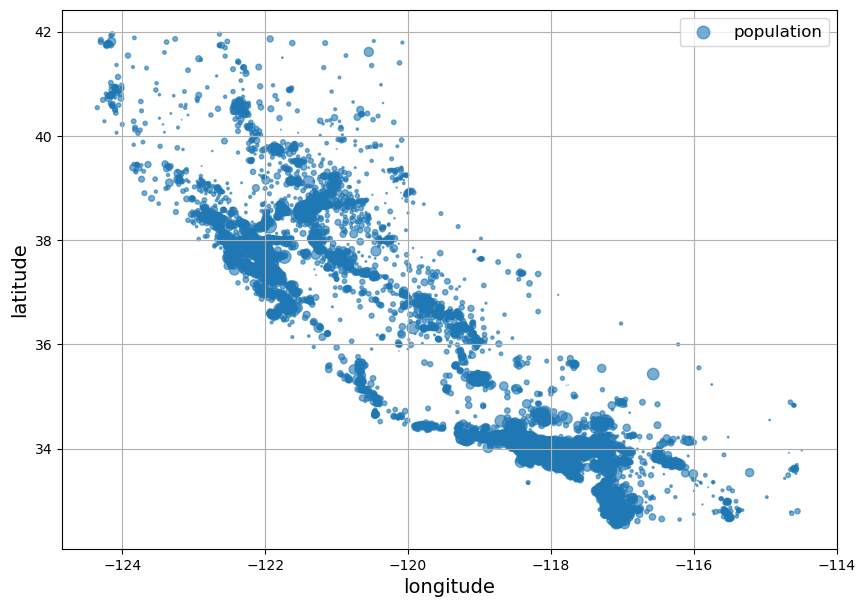

In [20]:
housing.plot(kind="scatter", 
             x="longitude",
             y="latitude",
             grid=True,
             s=housing["population"] / 100, label="population",
             alpha=0.6,
             legend=True,
             sharex=False,
             figsize=(10, 7))

plt.show()

### 피어슨 상관관계

앞으로 훈련시킬 모델은 어떤 구역의 중위 주택가격을 제외한 다른 특성이 주어졌을 때
해당 구역의 중위 주택가격을 예측해야 한다.
따라서 중위 주택가격과 상관관계가 높은 특성을 미리 확인해볼 필요가 있다.

특성들 사이의 선형 상관관계를 피어슨 상관계수로 계산한다.
단, 수치형 특성만 대상으로 한다.

In [21]:
corr_matrix = housing.corr(numeric_only=True)

Seaborn 라이브러리의 히트맵 함수를 이용하여 상관관계의 강도를 시각화해본다.

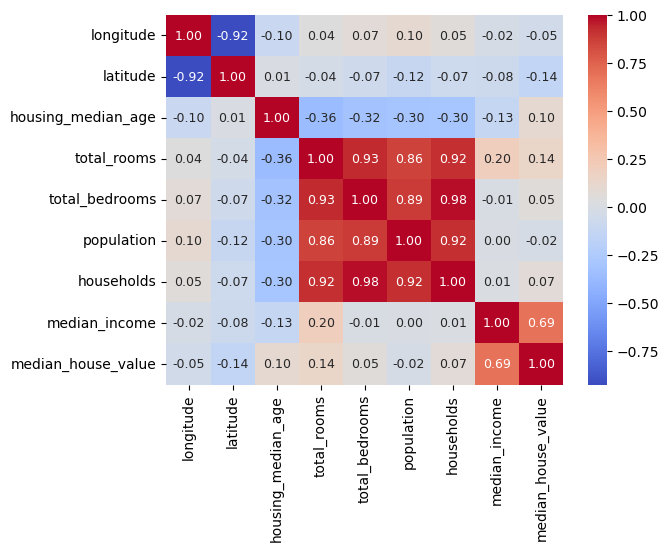

In [22]:
import seaborn as sns
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            annot_kws={"size": 9})
plt.show()

중위 주택가격과 중위소득의 상관계수가 0.68로 상당히 높다.
이는 중위소득이 올라가면 중위 주택가격도 상승하는 경향이 꽤 강하게 있음을 의미한다.
아래 산점도가 이 사실을 잘 확인시켜준다. 

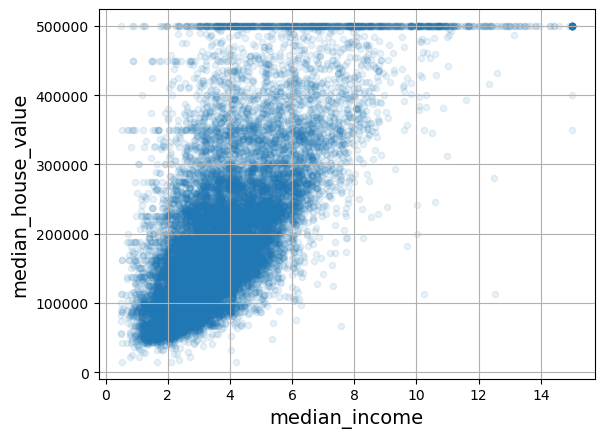

In [23]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)

plt.show()

## 타깃 대 입력 데이터셋

지도학습 방식으로 중위 주택가격을 예측하는 모델을 훈련시키려면
훈련셋을 타깃셋과 입력 데이터셋으로 분리해야 한다.
입력 데이터셋 또한 일반적으로 훈련셋으로 불린다.

In [24]:
# 훈련셋 (입력 데이터셋)
housing = strat_train_set.drop("median_house_value", axis=1)

# 타깃셋
housing_labels = strat_train_set["median_house_value"].copy()

**참고:**

- 이전 셀의 코드는 `housing` 데이터프레임 새롭게 정의한다.
    이렇게 하는 이유는 입력 데이터셋과 타깃셋을 구분하는 과정을 포함하여 앞으로 설명할 모든 전처리 과정을 한 번에 처리할 자동화된 '변환 파이프라인'을 구축하기 위함이다.

- `strat_train_set.drop()` 함수 또한 새로운 객체를 생성함에 주목한다.
    단, `inplace=True` 키워드 인자를 사용하지 않아야 한다.

## 데이터 정제와 전처리

데이터 탐색을 통해 확인한 지도학습 회귀 모델을 훈련시키기 위해 먼저
적절한 훈련셋(입력 데이터셋)을 준비해야 한다.
적절한 훈련셋(입력 데이터셋) 준비는 데이터 정제와 데이터 전처리 과정으로 이루어진다.

### 데이터 정제

먼저 데이터 정제<font size='2'>Data Cleanign</font>는 
일반적으로 훈련셋(입력 데이터셋)에 포함된 결측치 처리, 이상치와 노이즈 제거 등을 의미한다.
캘리포니아 주택 가격 데이터셋의 경우 구역별 총 방 수를 의미하는 `total_rooms` 특성에
포함되어 있는 결측치를 어떻게 다를 것인지 결정해야 한다.
이상치와 노이즈에 대해서는 여기서는 다루지 않는다.

### 데이터 전처리

데이터 전처리<font size='2'>Data Preprocessing</font>는
모델 훈련에 적합한 훈련셋(입력 데이터셋)을 만들어가는 과정을 가리킨다.
예를 들어, 캘리포니아 주택 가격 데이터셋에 포함된 수치형 특성과 범주형 특성에 대해
각각 아래 전처리 과정을 거친다.

* 범주형 특성 전처리: 원-핫-인코딩
* 수치형 특성 전처리: 특성 스케일링과 특성 조합

이에 더해 다음 전처리 과정도 진행한다.

- 비율 특성 추가: 침실 비율, 가구당 방 수, 가구당 평균 가구원 수
- 로그 변환 대상 특성: `"total_bedrooms"`, `"total_rooms"`, `"population"`, `"households"`, `"median_income"`
- 구역 군집 특성 추가: 위도와 경도 정보를 활용하여 유사한 구역끼리 구성된 군집으로 분류

## 사이킷런 API 활용

데이터 정제와 전처리 전과정을 사이킷런 라이브러리에서 제공하는 API를 활용한다.
먼저 사이킷런 API의 기본 특성을 살펴본 다음에 앞서 언급된 정제와 전처리 내용을 
처리하는 각각의 API를 하나씩 살펴본다.
그런 다음 사이킷런 API를 연동하여 정제와 전처리 전 과정을 
한꺼번에 순차적으로 처리하는 파이프라인<font size='2'>pipeline</font>으로 구성하여
자동화는 방식까지 소개한다.

**주의 사항**

여기서는 사이킷런 API를 활용한 데이터 정제와 전처리 사용법을 구체적인 예제를 이용하여 소개한다.
하지만 실제 캘리포니아 주택 가격 데이터셋의 변환은 
맨 나중에 여기서 소개된 API들 조합하여
한꺼번에 처리할 예정이다.

### 결측치 처리

`'total_bedrooms'` 특성에 결측치(`NaN`)가 일부 포함되어 있다.

**결측치가 하나라도 포함된 행 확인**

- `total_bedrooms`에만 총 168개의 결측치 포함됨.
- `null_rows_idx`: 결측치가 위치한 행만 선택하기 위한 부울 마스크

In [25]:
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
2348,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN
366,-122.50,37.75,44.0,1819.0,NaN,1137.0,354.0,3.4919,NEAR OCEAN
18241,-121.44,38.54,39.0,2855.0,NaN,1217.0,562.0,3.2404,INLAND
18493,-116.21,33.75,22.0,894.0,NaN,830.0,202.0,3.0673,INLAND


아래 코드로도 확인 가능

In [26]:
housing.loc[null_rows_idx].info()

<class 'pandas.DataFrame'>
Index: 168 entries, 14452 to 16519
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           168 non-null    float64
 1   latitude            168 non-null    float64
 2   housing_median_age  168 non-null    float64
 3   total_rooms         168 non-null    float64
 4   total_bedrooms      0 non-null      float64
 5   population          168 non-null    float64
 6   households          168 non-null    float64
 7   median_income       168 non-null    float64
 8   ocean_proximity     168 non-null    str    
dtypes: float64(8), str(1)
memory usage: 14.5 KB


**SimpleImputer 변환기**

`SimpleImputer` 변환기를 활용하여 수치형 결측치를 해당 특성의 중앙값<font size='2'>median</font>으로 대체한다.
아래 코드는 결측치를 해당 특성의 중앙값으로 대체하는 기능을 갖는
`SimpleImputer` 변환기 객체를 `imputer`에 할당한다.

In [27]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

`SimpleImputer` 변환기는 수치형 특성에 대해서만 작동한다.
아래 코드는 해안 근접도 특성을 제외한 나머지 수치형 특성만으로
구성된 데이터프레임을 대상으로 모든 결측치를 해당 특성의 중앙값으로
대체하기 위해 필요한 특성별 중앙값을 찾아 `imputer`가 가리키는 변환기 객체에 저장한다.

In [28]:
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


`fit()` 메서드가 찾아낸 특성별 중앙값 정보는 변환기 객체의 `statistics_` 속성에 저장된다.

In [29]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

`imputer` 변환기 객체의 `transform()` 메서드는 앞서 찾아낸 특성별 중앙값를 이용하여 각 특성에 포함된 모든 결측치를 대체한 새로운 **넘파이 어레이**를 생성한다.

In [30]:
X = imputer.transform(housing_num)

In [31]:
type(X)

numpy.ndarray

`fit_transform()` 메서드는 `fit()` 메서드와 `transform()` 메서드를 연속으로 호출하기에
`X`를 다음과 같이 바로 생성할 수 있다.

In [32]:
X = imputer.fit_transform(housing_num)

데이터프레임이 아닌 넘파이 어레이를 생성하는 과정에서 잊혀진 특성 이름은
변환기 객체의 `feature_names_in_` 속성으로 저장되어 있다.

In [33]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

특성명을 활용하여 다시 데이터프레임으로 변환한다.

In [34]:
housing_tr = pd.DataFrame(X, 
                          columns=housing_num.columns,
                          index=housing_num.index)

`total_bedrooms`의 모든 결측치가 해당 특성의 중앙값로 대체되었음을 확인할 수 있다.

In [35]:
housing_tr.loc[null_rows_idx]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020
...,...,...,...,...,...,...,...,...
2348,-122.70,38.35,14.0,2313.0,434.0,954.0,397.0,3.7813
366,-122.50,37.75,44.0,1819.0,434.0,1137.0,354.0,3.4919
18241,-121.44,38.54,39.0,2855.0,434.0,1217.0,562.0,3.2404
18493,-116.21,33.75,22.0,894.0,434.0,830.0,202.0,3.0673


결측치를 대체하는 전략은 변환기 객체의 `strategy` 속성에 저장되어 있다.

In [36]:
imputer.strategy

'median'

참고로 `SimpleImputer`의 객체를 생성할 때 사용할 수 있는 `strategy`는 다음과 같다.

- `"mean"`: 평균값으로 채움 (수치형 데이터 전용) - 기본값
- `"median"`: 중간값(중앙값)으로 채움 (수치형 데이터 전용)
- `"most_frequent"`: 최빈값(가장 자주 등장하는 값)으로 채움 (수치형/문자열 데이터 모두 가능)
- `"constant"`: 지정한 상수로 채움. 
    `strategy` 매갭변수에 대한 키워드 인자 이외에 `fill_value` 매개변수의 키워드 인자로 지정

    ```python
    SimpleImputer(strategy="constant", fill_value="채울값")
    ```

### 원-핫 인코딩

해안 근접도(`ocean_proximity`)는 문자열을 사용한다.

In [37]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


사이킷런의 `OneHotEncoder` 변환기가 원-핫 인코딩을 지원한다.

In [38]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

결과는 **희소 행렬**<font size='2'>sparse array</font> 형식이기에
내부를 보여주지 않는다.

In [39]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

희소행렬은 대다수의 항목이 0인 큰 모양의 2차원 어레이를 메모리 효율적으로 다루기 위해 사용한다.
예를 들어, 훈련셋의 해안 근접도 특성을 원-핫 인코딩하면
(16512, 5) 모양의 어레이가 생성되는 데 그중에 16512개의 항목만 1이고 나머지는 0이다.
이런 경우 0이 아닌 항목의 위치 정보와 원래 행렬의 크기만 알면 되기에
희소 행렬을 대신 사용하곤 한다.

반면에 희소 행렬에 `toarray()` 메서드를 적용하면 밀집 행렬<font size='2'>dense array</font>로
변환되어 내용이 확인된다.

In [40]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

**`sparse_output=False`** 옵션

원-핫 인코딩 변화기를 지정할 때 `sparse_output=False` 옵션을 지정하면
결과가 항상 밀집 어레이로 계산된다.

In [41]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

결과적으로 원래 하나의 `ocean_proximity` 특성이 원-핫 인코딩에 의해 5개의 특성값으로 변환되었다.
예를 들어 `housing`에 포함된 0번 인덱스 구역의 `ocean_proximity`는 `NEAR BAY`이다.

In [42]:
housing_cat.iloc[0]

ocean_proximity    NEAR BAY
Name: 13096, dtype: str

`NEAR BAY`는 원-핫 인코더가 정한 특성값들의 순서상 3번 인덱스에 해당함을
`cat_encoder.categories_` 속성으로 확인된다.

In [43]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

따라서 해당 구역의 해안 근접도 특성값이 다음과 같이 길이가 5이면서
3번 인덱스의 값만 1이고 나머지는 0인 1차원 어레이로 변환되었다.

In [44]:
housing_cat_1hot[0]

array([0., 0., 0., 1., 0.])

원-핫 인코딩 과정에서 새로 생성되는 특성들을 이름은 다음과 같으며,
**더미 특성**<font size='2'>dummy features</font>으로 불린다.

새롭게 생성된 5개의 특성은 기존에 주어진 특성 대신 사용되는 특성이라는 의미에서 더미 특성으로 불린다.
여기서는 해안 근접도 특성에 사용된 실제 값을 대변하는 특성으로 사용된다.

In [45]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

더미 특성정보를 활용하여 데이터프레임으로 다음과 같이 변환할 수 있다.

In [46]:
pd.DataFrame(housing_cat_1hot,
             columns=cat_encoder.get_feature_names_out(),
             index=housing_cat.index)

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,0.0,0.0,0.0,1.0,0.0
14973,1.0,0.0,0.0,0.0,0.0
3785,0.0,1.0,0.0,0.0,0.0
14689,0.0,1.0,0.0,0.0,0.0
20507,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
14207,1.0,0.0,0.0,0.0,0.0
13105,0.0,1.0,0.0,0.0,0.0
19301,0.0,0.0,0.0,0.0,1.0
19121,1.0,0.0,0.0,0.0,0.0


### 특성 스케일링

**min-max 스케일링**

min-max 스케일링은 정규화의 한 방식이다.
아래 식을 이용하여 특성값 $x$를 0에서 1 사이의 값으로 변환한다.
$max$ 와 $min$ 은 각각 해당 특성값들의 최댓값과 최솟값을 가리킨다.

$$
\frac{x-min}{max-min}
$$

min-max 스케일링은 이상치에 매우 민감하다.
예를 들어 이상치가 매우 크면 분모가 분자에 비해 훨씬 크게 되어 변환된 값이 0 근처에 몰리게 된다.
사이킷런의 `MinMaxScaler` 변환기가 min-max 스케일링을 지원한다.

In [47]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [48]:
housing_num_min_max_scaled

array([[-0.60851927,  0.11702128,  1.        , ..., -0.80701754,
        -0.61433638, -0.7794789 ],
       [ 0.21095335, -0.66170213,  0.52941176, ..., -0.91866029,
        -0.86708979, -0.22929339],
       [-0.51926978,  0.23617021,  0.25490196, ..., -0.93141946,
        -0.92458466, -0.73336919],
       ...,
       [ 0.47870183, -0.99148936, -0.52941176, ..., -0.65513434,
        -0.71663244, -0.50873781],
       [ 0.20689655, -0.6787234 ,  0.41176471, ..., -0.78873758,
        -0.68751167, -0.49716556],
       [-0.60649087,  0.08723404,  0.68627451, ..., -0.91669734,
        -0.92122457, -0.61608805]], shape=(16512, 8))

**표준화**

표준화<font size='2'>standardization</font>는 아래식을 이용하여 특성값 $x$를 변환한다.
단, $\mu$ 와 $\sigma$ 는 각각 해당 특성값들의 평균값과 표준편차를 가리킨다.

$$
\frac{x-\mu}{\sigma}
$$

표준화 스케일링으로 변환된 특성은 
평균값은 0, 표준편차는 1인 분포를 따르며, 이상치에 상대적으로 덜 영향을 받는다.
사이킷런의 `StandardScaler` 변환기가 표준화 스케일링을 지원한다.

In [49]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

In [50]:
housing_num_std_scaled

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.13746004,
         1.39481249, -0.93649149],
       [ 0.59639445, -0.702103  ,  0.90762971, ..., -0.69377062,
        -0.37348471,  1.17194198],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.78876841,
        -0.77572662, -0.75978881],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  1.26829911,
         0.67913534,  0.1010487 ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.27356264,
         0.88286825,  0.14539615],
       [-1.41803793,  0.94797769,  1.22545939, ..., -0.67915557,
        -0.75221898, -0.31034135]], shape=(16512, 8))

### 로그 변환

데이터셋이 두터운 꼬리 분포를 따르는 경우, 
즉 히스토그램이 지나치게 한쪽으로 편향된 경우
스케일링을 적용하기 전에 먼저
로그 함수 $\log(x)$를 적용하여 어느 정도 좌우 균형이 잡힌 분포로 변환할 것을 권장한다.
좌우 균형이 잘 잡힌 특성들을 활용하면 머신러닝 모델의 훈련이 보다 잘된다.

**`FunctionTransformer` 변환기**

로그 변화처럼 미리 어떤 정보를 확인할 필요 없이 바로 데이터 변환을 진행할 수
있다면, `fit() 메서드`를 굳이 사용할 필요가 없다. 
이런 경우 `FunctionTransformer` 변환기를 활용한다.

In [51]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log)
log_pop = log_transformer.transform(housing[["population"]])

In [52]:
log_pop

,population
13096,7.362645
14973,6.501290
3785,6.331502
14689,7.520235
20507,7.555905
...,...
14207,6.843750
13105,7.257708
19301,7.942362
19121,7.452982


아래 그림은 구역별 인구로 구성된 `population` 특성값에 로그함수를 적용할 때 분포가 보다 균형잡히는 것을 잘 보여준다.

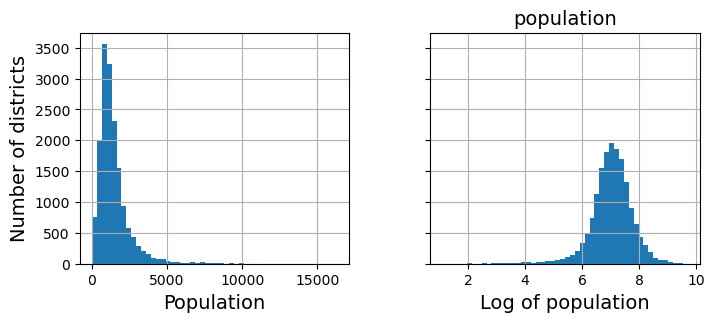

In [53]:
# extra code – this cell generates Figure 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
log_pop.hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

plt.show()

### 비율 변환

두 개의 특성 사이의 비율을 계산하여 다음 새로운 특성 세 개를 생성할 예정이다.

- 침실 비율: `housing['total_bedrooms'] / housing['total_rooms']`
- 가구당 방 수: `housing['total_bedrooms'] / housing['households']`
- 가구당 평균 가구원수: `housing['population'] / housing['households']`

비율 변환 또한 앞서 설명한 `FunctionTransformer` 변환기를 활용하며, 
아래 코드가 간단한 사용법을 보여준다.

- `sample_array`: (2, 2) 모양의 어레이
- `ratio_transformer`: 0번 열을 1번 열로 나눈값으로 구성된 어레이로 변환하는 변환기

In [54]:
sample_array = np.array([[1., 2.],
                         [3., 4.]])

In [55]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
transformed_array =ratio_transformer.transform(sample_array)

In [56]:
transformed_array

array([[0.5 ],
       [0.75]])

### 사용자 정의 변환기

훈련셋 준비 과정에서 경우에 따라 사용자가 직접 변환기를 구현해야할 필요가 있다.
여기서는 훈련셋에 포함된 구역들의 위도와 경도 정보를 이용하여 서로 가깝게 위치한 구역들로 묶어
총 10개의 군집<font size='2'>cluster</font>으로 구분하는 변환기를
직접 정의하여 활용한다.

In [57]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

아래 코드는 구역의 위도와 경도 정보를 이용하여 10개의 군집을 형성한다.

- `transform()` 메서드: 각 샘플과 10개의 군집의 중심<font size='2'>centroid</font> 사이의 유사도 점수를 계산한다.
- 구역별로 계산된 10개의 유사도 점수는 새로운 10개의 특성으로 훈련셋(입력 데이터셋)에 추가될 예정이다.

In [58]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])

c:\Users\gslee\miniforge3\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


처음 3개 샘플과 각 군집의 중심에 대한 유사도 점수는 다음과 같다.
예를 들어 첫째 샘플의 경우 7번 인덱스의 값이 0.98로 가장 큰데,
이는 첫째 샘플이 8번째 군집의 중심와 가장 유사함(위도와 경도 기준)을 의미한다.

In [59]:
similarities[:3].round(2)

array([[0.46, 0.  , 0.08, 0.  , 0.  , 0.  , 0.  , 0.98, 0.  , 0.  ],
       [0.  , 0.96, 0.  , 0.03, 0.04, 0.  , 0.  , 0.  , 0.11, 0.35],
       [0.34, 0.  , 0.45, 0.  , 0.  , 0.  , 0.01, 0.73, 0.  , 0.  ]])

아래 그래프는 10개 군집의 중심과 각 구역의 위도, 경도 정보를 활용한 산점도이다.

- &#128473; 표시는 각 군집의 중심, 즉 각 군집의 중심 구역을 표시한다.
- 색상은 구역이 속한 군집의 중심과의 유사도를 가리킨다. 
    빨간색이 강해질 수록 해당 구역이 속한 군집의 중심과의 유사도(위도와 경도 기준)가 커짐을,
    즉 가까워짐을 의미한다.
- 점의 크기는 구역 인구에 비례한다.

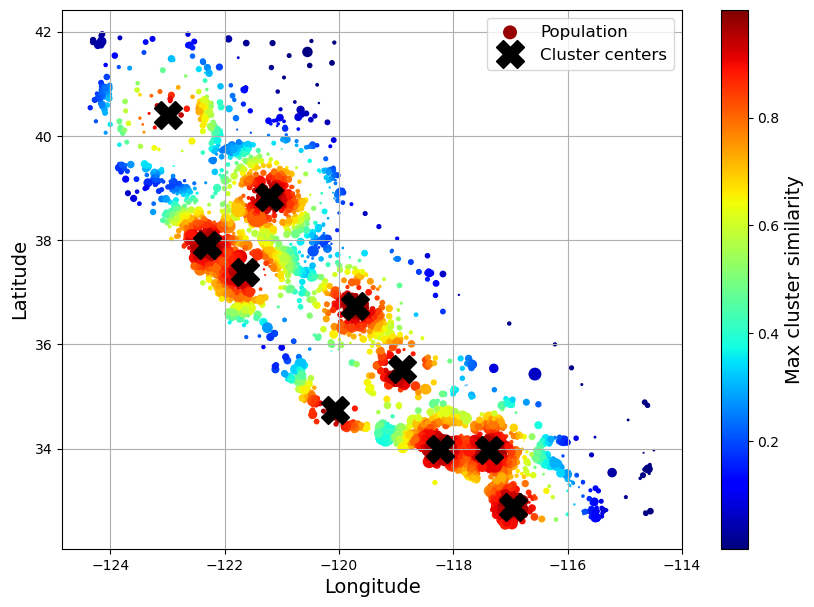

In [60]:
# extra code – this cell generates Figure 2–19

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})

# 점 색깔 지정용 특성
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

# 위도, 경도 활용 산점도
# 점 크기는 인구에 비례, 점 색깔은 군집의 중심과의 유사도에 비례
housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))

# 군집의 중심: X 표시
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")

# 범례 표시
plt.legend(loc="upper right")

plt.show()

아래 그래프와 비교해보면 일부 군집, 특히 해안가에 위치한 밀도가 높은 군집에서는 군집 중심에 가까울 수록
중위 주택가격이 높아짐을 알 수 있다.
머신러닝 모델이 이런 특성을 활용할 수 있도록 단순한 위도, 경도 정보대신 군집과 유사도 정보를 새로운 특성으로
제공하면 모델의 성능이 보다 좋아질 수 있다.

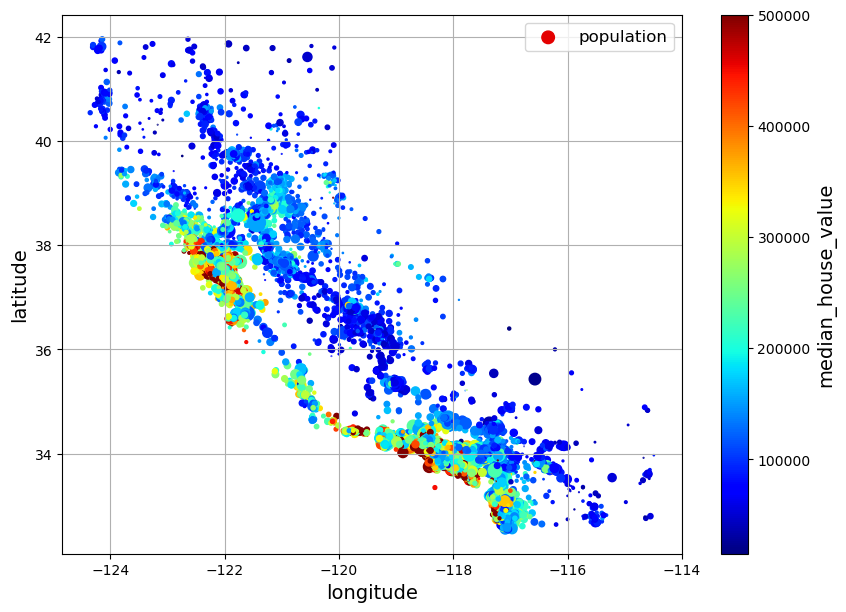

In [61]:
# median_house_value 특성이 없는 housing 변수 대신 원본 훈련 세트인 strat_train_set을 사용
strat_train_set.plot(kind="scatter",
             x="longitude",
             y="latitude",
             grid=True,
             s=strat_train_set["population"] / 100, label="population", # 여기도 수정
             c="median_house_value",
             cmap="jet",
             colorbar=True,
             legend=True,
             sharex=False,
             figsize=(10, 7))
plt.show()

## 파이프라인

데이터 정제와 전처리의 모든 단계가 정확한 순서대로 진행되어야 한다.
사이킷런은 여러 변환기를 순차적으로 또는 병렬적으로 실행하는
파이프라인 기능을 지원한다.

사이킷런에서 제공하는 파이프라인 관련 주요 API는 다음과 같다.

| API | 설명 |
|---|---|
| `Pipeline` 클래스 | 이름으로 구분된 여러 추정기(변환기, 예측기)를 순차적으로 연결하여 파이프라인 구성. 단 예측기가 사용되는 경우 맨 마지막에 추가 |
| `make_pipeline()` 함수 | 추정기 이름 지정 없이 간편하게 `Pipeline` 객체 생성 |
| `ColumnTransformer` 클래스 | 특성마다 다른 변환기를 병렬 적용 후 결과 병합 |
| `make_column_transformer()` 함수 | 이름 지정 없이 간편하게 `ColumnTransformer` 객체 생성 |

**주의 사항**

여기서는 먼저 언급된 파이프라인 관련 주요 API 활용법을 소개한다.
그런 다음 소개된 모든 API를 조합해서 실제 캘리포니아 주택 가격 데이터셋의 변환에 사용되는 파이프라인은 지정한다.

### `Pipeline` 클래스

파이프라인으로 정의된 추정기가 변환기인지, 예측기인지 여부는
마지막 추정기에 의해 결정된다.
즉, 마지막 추정기가 변환기인지, 예측기인지에 따라
해당 파이프라인이 변환기 또는 예측기가 된다.
`num_pipeline`를 구성하는 마지막 추정기가 변환기이기에
생성된 파이프라인 역시 변환기가 된다.

파이프라인을 호출하면 마지막 추정기 이전까지의 변환기에 대해서는
`fit_transform()` 메소드가 연속적으로 호출된다.
따라서 파이프라인에 포함된 마지막 추정기를 제외한 모든 추정기는 변환기 이어야 한다.

일단 여기서는 변환기 파이프라인만 활용하며,
이후 머신러닝 모델을 구현할 때 예측기를 마지막 추정기로 지정하는
파이프라인을 이용한다.

**수치형 특성 변환 기본 파이프라인**

In [62]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

### `make_pipeline()` 함수

`make_pipeline()` 함수를 이용할 수도 있다.
단, 각 추정기의 이름은 자동으로 생성된다.

In [63]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

파이프라인 활용법은 변환기/예측기 활용법과 동일하다.

- `fit_transform()` 메서드를 호출하면 파이프라인에 포함된 변환기 각각에 대해 
    `fit_transform()` 메서드가 연속적으로 호출된다.

In [64]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [65]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index)

In [66]:
df_housing_num_prepared.head(2)  # extra code

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942


**파이프라인 구조**

생성된 파이프라인의 구조를 그래프로 확인할 수 있다.

In [67]:
from sklearn import set_config

set_config(display='diagram')

num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

생성된 파이프라인의 구조를 파이프라인 객체의 속성으로도 확인할 수 있다.

In [68]:
num_pipeline.steps

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

마치 리스트처럼 인덱싱을 사용하면 파이프라인에 포함된
변환기/예측기를 하나씩 지정할 수도 있다.

In [69]:
num_pipeline[1]

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [70]:
num_pipeline[:-1]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has 

변화기의 지정된 이름을 이용한 인덱싱도 가능하다.

In [71]:
num_pipeline.named_steps

{'simpleimputer': SimpleImputer(strategy='median'),
 'standardscaler': StandardScaler()}

In [72]:
num_pipeline.named_steps["simpleimputer"]

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


파이프라인에 포함된 변환기의 속성도 직접 지정할 수도 있다.
아래 코드는 표준화 변환기의 결측치 처리 전략을 중앙값을
사용하는 방식으로 지정한다.

In [73]:
num_pipeline.set_params(simpleimputer__strategy="median")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

### `ColumnTransformer` 클래스

특성별로 파이프라인을 지정할 수 있다.

In [74]:
from sklearn.compose import ColumnTransformer

# 수치형 특성 리스트 지정
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
# 범주형 특성 리스트 지정
cat_attribs = ["ocean_proximity"]

# 범주형 특성 변환 파이프라인
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

# 전체 특성 변환기
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

**`make_column_selector()` 함수**

파이프라인에 포함되는 각 변환기를 적용할 특성을 일일이 나열하는 일이 어려울 수 있다.
이때 지정된 자료형을 사용하는 특성들만을 선택해주는 `make_column_selector()` 함수를 
유용하게 활용할 수 있다.

- `make_column_selector(dtype_include=np.number)`: 수치형 특성 모두 선택
- `make_column_selector(dtype_include=object)`: 범주형 특성 모두 선택

따라서 위 `preprocessing` 변환기를 아래와 같이 정의할 수 있다.

```python
preprocessing = ColumnTransformer([
    ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)
])
```

### `make_column_transformer` 클래스

`make_column_transformer()` 함수를 이용하여 `ColumnTransformer` 변환기를
생성할 수도 있다.
단, 각 변환기의 이름은 자동으로 생성된다.

In [75]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

### 캘리포니아 데이터셋 변환 파이프라인

`ColumnTransformer` 클래스와 `Pipeline` 클래스를 이용하여
캘리포니아 주택 가격 데이터의 입력 데이터셋을 한꺼번에 변환하는 
파이프라인 변환기를 아래 코드에서 정의된 네 개의 파이프라인을 이용하여 구현한다.

In [76]:
# 파이프라인 1: 두 수치형 특성의 비율을 계산하는 사용자 정의 변환기
def column_ratio(X):
    return X[:, [0]] / X[:, [1]] # 1번 특성에 대한 0번 특성의 비율율

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # 새로 생성되는 특성값들의 특성명

ratio_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(column_ratio, feature_names_out=ratio_name),
    StandardScaler())

# 파이프라인 2: 여러 수치형 특성에 로그 변환을 적용하는 사용자 정의 변환기
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

# 파이프라인 3: 위도와 경도를 활용하여 군집의 중심과의 유사도를 계산하는 사용자 정의 변환기
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

# 파이프라인 4: 기타 특성에 적용될 기본 수치형 특성 변환기
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())

**종합**

앞서 언급된 모든 변환기를 특성별로 적용하는 변환기를
`ColumnTransformer` 클래스를 이용하여 정의한다.

`remainder=default_num_pipeline`는
그때까지 언급되지 않은 나머지 특성들을 처리하는 변환기를
키워드 인자로 지정한다.
`remainder` 매개변수의 키워드 인자로 나머지 특성을 삭제하는 것을 지정하는 
`drop` 이 기본값이며, 그 이외에 `passthrough`는 나머지 특성은 
변환하지 않고 그대로 두어야 함을 의미한다.

아래 코드에서는 마지막으로 남은 '주택 중위연령'을 가리키는 `housing_median_age` 특성에
기본 변환기를 적용하도록 지정한다.

In [77]:
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline, ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline, ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline, ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # 남은 특성 하나: housing_median_age

모든 파이프라인 변환기의 사용법은 동일하다.
아래 코드는 `housing` 훈련셋을 특성별로 지정된 변환을 실행한다.
반환값이 넘파이 어레이임에 주의한다.

In [78]:
housing_prepared = preprocessing.fit_transform(housing)

In [79]:
housing_prepared

array([[ 1.84662439, -0.86602737, -0.33020372, ...,  1.        ,
         0.        ,  1.86111875],
       [-0.5081207 ,  0.0245495 , -0.25361631, ...,  0.        ,
         0.        ,  0.90762971],
       [-0.20215476, -0.04119332, -0.05104091, ...,  0.        ,
         0.        ,  0.35142777],
       ...,
       [-0.24249175, -0.10998748,  0.15854151, ...,  0.        ,
         1.        , -1.23772062],
       [ 0.25977479, -0.36093745, -0.21033248, ...,  0.        ,
         0.        ,  0.66925745],
       [ 3.61270996, -1.32397227,  0.04958379, ...,  0.        ,
         1.        ,  1.22545939]], shape=(16512, 24))

특성이 총 24개로 늘었으며,
특성별 이름은 변환기의 `get_feature_names_out()` 메서드로 확인한다.

- 비율 변환기 적용: 3개의 새로운 특성 추가.
- 위도-경도 군집 특성: 10개의 특성으로 변환. 위도와 경도 2개의 특성 대신 10개 특성 새로 추가.
- 해안 근접도 더미 특성: 5개로 변환. 기존 해안 근접도 특성 제거 후 5개 더미 특성 추가.
- 나머지 특성: 1개 (중위 주택연령) 변환. 특성수는 그대로 유지됨

In [80]:
housing_prepared.shape

(16512, 24)

In [81]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

`preprocessing`에 의한 변환 과정에서 새로 생성된 특성 이름과 함께 확인하면 다음과 같다.

In [82]:
housing_prepared_df = pd.DataFrame(housing_prepared,
                                   columns=preprocessing.get_feature_names_out(),
                                   index=housing.index)
housing_prepared_df.head()

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0 similarity,geo__Cluster 1 similarity,...,geo__Cluster 6 similarity,geo__Cluster 7 similarity,geo__Cluster 8 similarity,geo__Cluster 9 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age
13096,1.846624,-0.866027,-0.330204,1.324114,0.637892,0.456906,1.310369,-1.071522,4.581829e-01,1.241847e-14,...,8.489216e-04,9.770322e-01,2.382191e-08,3.819126e-18,0.0,0.0,0.0,1.0,0.0,1.861119
14973,-0.508121,0.024550,-0.253616,-0.252671,-0.063576,-0.711654,-0.142030,1.194712,6.511495e-10,9.579596e-01,...,5.614049e-27,1.260964e-13,1.103491e-01,3.547610e-01,1.0,0.0,0.0,0.0,0.0,0.907630
3785,-0.202155,-0.041193,-0.051041,-0.925266,-0.859927,-0.941997,-0.913030,-0.756981,3.432506e-01,4.261141e-15,...,5.641131e-03,7.303265e-01,2.508224e-08,2.669659e-18,0.0,1.0,0.0,0.0,0.0,0.351428
14689,-0.149006,-0.034858,-0.141475,0.952773,0.943475,0.670700,0.925373,-0.912253,2.244844e-15,2.704823e-01,...,5.913326e-35,5.201263e-20,1.712982e-03,8.874598e-01,0.0,1.0,0.0,0.0,0.0,-0.919891
20507,0.963208,-0.666554,-0.306148,1.437622,1.003590,0.719093,1.481464,0.034537,1.090228e-11,9.422206e-01,...,5.421817e-30,1.048030e-15,2.568824e-02,5.279506e-01,0.0,0.0,0.0,0.0,1.0,0.589800


In [83]:
housing_prepared_df.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   bedrooms__ratio                  16512 non-null  float64
 1   rooms_per_house__ratio           16512 non-null  float64
 2   people_per_house__ratio          16512 non-null  float64
 3   log__total_bedrooms              16512 non-null  float64
 4   log__total_rooms                 16512 non-null  float64
 5   log__population                  16512 non-null  float64
 6   log__households                  16512 non-null  float64
 7   log__median_income               16512 non-null  float64
 8   geo__Cluster 0 similarity        16512 non-null  float64
 9   geo__Cluster 1 similarity        16512 non-null  float64
 10  geo__Cluster 2 similarity        16512 non-null  float64
 11  geo__Cluster 3 similarity        16512 non-null  float64
 12  geo__Cluster 4 similarity     

## 모델 선택과 훈련

`preprocessing`에 의해 변환되는 데이터프레임은 예측기 모델의 훈련에
바로 사용될 수 있다.
즉, 이제 머신러닝 예측기 모델의 훈련셋으로 바로 사용할 수 있다.

하지만 여기서는 데이터 변환과 모델 훈련을 분리해서 진행하는 대신
변환기와 예측기를 하나의 파이프라인으로 묶어
데이터 변환과 모델 훈련을 동시에 진행하는 방법을 선택해서 소개한다.

`preprocessing`이 가리키는 변환기와 함께 묶여 하나의 파이프라인으로 구성될 예측기로
사이킷런의 회귀 모델 세 개를 활용한다.
각 모델의 자세한 특징과 상세 설명은 이어지는 장에서 하나씩 소개할 예정이며,
여기서는 모델 선택에 따른 성능과 보다 좋은 모델을 훈련시키는 방법을 자세히 소개한다.

### 모델 훈련과 평가

**선형회귀 모델 활용**

- 훈련

In [84]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: fl

- 예측

In [85]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)  # -2 = rounded to the nearest hundred

array([246000., 372700., 135700.,  91400., 330900.])

실제 주택 중위가격은 다음과 같으며, 예측값과 오차가 꽤 난다.

In [86]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [87]:
error_ratios = housing_predictions[:5].round(-2) / housing_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-46.3%, -23.0%, 33.4%, -4.9%, -8.5%


- 훈련셋에 대한 RMSE

예측값의 RMSE가 68973 정도로 많이 높다.
모델 훈련이 제대로 진행되지 못한 과소 적합이 발행하였으며 이는 선형회귀 모델이 적절하지 않음을 의미한다.

In [88]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68972.88910758478

**결정트리 회귀 모델 활용**

- 훈련

In [89]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshol

- 훈련셋에 대한 RMSE

RMSE가 0으로 나온다.
이는 결정트리 모델이 심하게 과대 적합되었음을 의미한다.
이런 모델은 전혀 의미가 없다.

In [90]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

**랜덤 포르게트 회귀 모델**

In [91]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(n_estimators=100, random_state=42))

- 훈련

In [92]:
forest_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshol

- 훈련셋에 대한 RMSE

RMSE가 결정트리보다는 당연히 높지만 선형회귀 모델 보다는 훨씬 낮다.

In [93]:
housing_predictions = forest_reg.predict(housing)
forest_rmse = root_mean_squared_error(housing_labels, housing_predictions)
forest_rmse

17519.685029292894

### 교차 검증

**사이킷런의 `cross_val_score()` 함수**

`cross_val_score()` 함수는 지정된 모델을 k-겹 교차 검증을 활용하여 훈련과 평가를 동시에 진행한다.
교차검증은 다만 모델 평가용도로만 폴드를 구분하여 훈련할 뿐 훈련된 모델 객체 자체를 반환하지는 않는다.
예를 들어 아래 코드는 결정트리 모델에 대해 교차 검증을 실행한다.

`cross_val_score()` 함수 호출에 사용된 키워드 인자는 다음과 같다.

- `scoring="neg_mean_squared_error"` 옵션
    - 훈련중인 모델의 성능을 측정하는 **효용함수** 지정
    - 모델의 성능 측정값은 높을 수록 좋은 성능으로 평가되기에 회귀 모델의 경우 일반적으로 RMSE의 음숫값을 사용함.
- `cv=10`: 10-겹 교차 검증 진행

`cross_val_score()` 함수의 반환값은 `scoring="neg_mean_squared_error"` 옵션으로 인해 음수값이다.
따라서 다시 양수로 만들어서 `tree_rmses` 변수에 할당한다.

**결정트리 모델에 대한 교차 검증**

In [94]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

`cv=10` 설정에 의해 10 개의 폴드를 사용하며 매번 RMSE를 측정한다.

In [95]:
tree_rmses

array([64849.19574692, 67830.59296019, 66734.74035037, 66900.3640754 ,
       64289.37619843, 68243.50238557, 66988.9328623 , 68454.11092405,
       68659.29429046, 67183.49969976])

`pandas.Series` 로 변환하면 통계 정보를 쉽게 구할 수 있다.
결과가 이전에 하나의 결정트리 모델만 사용했을 때 보다 훨씬 나쁘다.

In [96]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     67013.360949
std       1460.198570
min      64289.376198
25%      66776.146282
50%      67086.216281
75%      68140.275029
max      68659.294290
dtype: float64

**선형회귀 모델에 대한 교차 검증**

결정트리 모델의 교차검증 보다 약간 나쁘게 나온다.

In [97]:
lin_rmses = -cross_val_score(lin_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count       10.000000
mean     70003.404818
std       4182.188328
min      65504.765753
25%      68172.065831
50%      68743.995249
75%      70344.943988
max      81037.863741
dtype: float64

**랜덤 포레스트 모델에 대한 교차 검증**

램덤 포레스트 모델에 교차 검증을 적용하면 보다 많은 시간이 걸린다 (몇 분 정도).
그만큼 랜덤 포레스트 모델이 보다 복잡한 훈련을 진행하기 때문이다.
하지만 결과적으로 랜덤 포레스트 회귀 모델의 성능이 보다 좋다.

In [98]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

교차 검증에 의한 RMSE 평균는 47,000 정도로 확인된다.

In [99]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47124.604437
std       1069.311372
min      45292.329302
25%      46712.106520
50%      47172.209883
75%      47561.377695
max      49354.705514
dtype: float64

훈련셋에 대한 RMSE가 17,519 정도인 것에 비하면 매우 높아졌다.
따라서 랜덤 포레스트 모델 또한 훈련셋에 너무 특화되어 있다, 즉 과대적합이 발생하였다.

## 모델 미세 조정

### 그리드 탐색

그리드 탐색에 사용될 모델을 전처리와 함께 지정한다.
파이프라인에 포함된 전처리와 예측기에 사용되는 하이퍼파라미터 중에서 미세조정에 사용될 하이퍼파라미터가 가질 수 있는 값들의 리스트를 지정한다.

총 15개의 하이퍼파라미터 조합에 대해 모델을 지정한 다음에
매번 3-겹 교차 검증을 실행하기에
아래 코드는 총 45번 훈련을 진행한다.

```
(3 * 3 + 2 * 3) * 3 = 45
```

아래 코드를 실행하면 컴퓨터 사양에 따라 몇 분 이상 걸릴 수 있다.

In [100]:
from sklearn.model_selection import GridSearchCV

# 랜덤 포레스트 모델과 전체 전처리 파이프라인을 하나로 묶은 파이프라인
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

# 하이퍼파라미터 조합: 3*3 + 2*3 조합 확인
# 전처리 변환기의 하이퍼파라미터(군집 수)와 랜덤 포레스트 모델의 하이퍼파라미터 (최대 특성 수) 대상 지정
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],  # 군집의 수
     'random_forest__max_features': [4, 6, 8]},     # 최대 특성 수
    {'preprocessing__geo__n_clusters': [12, 15],
     'random_forest__max_features': [8, 10, 12]},
]

# 그리드 탐색 객체 생성: 전체 파이프라인과 하이퍼파라미터 그리드, 교차 검증 분할 수, 평가 지표 지정
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')

# 그리드 탐색 수행
grid_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [12, 15], 'random_forest__max_features': [8, 10, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosit

**`full_pipeline.get_params().keys()`**

파이프라인에 포함된 변환기와 예측기의 하이퍼파라미터는 각 객체의 `get_params()` 메서드를 호출해서
각 객체별로 확인하거나,
파이프라인 자체의 `get_params()` 메서드를 호출하여 파이프라인 객체를
지정할 때 사용할 수 있는 하이퍼파라미터 전체를 확인할 수 있다.
예를 들어, 사용가능한 10개의 하이퍼파라미터는 다음과 같다.

In [101]:
(list(full_pipeline.get_params().keys()))[:10]

['memory',
 'steps',
 'transform_input',
 'verbose',
 'preprocessing',
 'random_forest',
 'preprocessing__force_int_remainder_cols',
 'preprocessing__n_jobs',
 'preprocessing__remainder__memory',
 'preprocessing__remainder__steps']

하지만 개별 객체의 하이퍼파라미터를 사이킷런 문서에서 하나씩 확인해서
모델 미세 조정에 사용하면 좋을 중요한 하이퍼파라미터를 지정할 것을 권장한다.
어떤 하이퍼파라미터가 중요한가는 앞으로 하나씩 알아나갈 것이다.

**그리드 탐색 결과**

- `grid_search.best_params_` 속성

그리드 탐색을 통해 찾아낸 최적의 하이퍼파라미터 조합은 다음과 같다.

In [102]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 8}

군집 수는 15개로, 랜덤 포레스트 모델의 `max_features` 하이퍼파라미터는 6으로
지정할 때 랜덤 포레스트 모델의 성능이 가장 좋았다는 의미다.

- `grid_search.best_estimator_` 속성

그리드 탐색을 통해 찾아낸 최적의 모델은 다음과 같다.

In [103]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, de

- `grid_search.cv_results_` 속성

그리드 탐색 과정에서 훈련된 15개 모델 각각의 평가지표를 확인할 수 있다.
원래 사전 자료형으로 지정되며,
키(key)는 랜덤 포레스트 모델의 하이퍼파라미터와 각 모델의 훈련 성능과 관련된다.

사전을 데이터프레임으로 변환하면 보다 보기가 편하다.
데이터프레임의 열은 사전 자료형의 키를 사용한다.

In [104]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True) # 평균 테스트 점수 기준으로 결과 정렬

# 일부 특성 및 점수 열만 선택하여 보기 좋게 정리
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]

cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

# 상위 성능 5개 조합 확인 
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,8,44027,44180,45007,44405
9,12,8,43995,44669,45658,44774
13,15,10,44403,44619,45424,44815
7,10,6,44251,44825,45611,44896
6,10,4,44351,45054,45975,45126


### 랜덤 탐색

그리드 탐색은 적은 수의 하이퍼파라미터 조합을 실험해볼 때만 유용하다.
반면에 하이퍼파라미터 탐색 공간이 커서 조합 경우의 수가 많아지면 훈련 시간이 너무
올래 걸려 활용하기 어렵다.
이런 경우 랜덤 탐색<font size='2'>randomized search</font>이 보다 효율적으로 최적의 하이퍼파라미터 조합을 찾아낼 수 있다.

아래 코드는 무작위로 선택한 10개의 하이퍼파라미터 조합에 대해 3-겹 교차 검증을 진행하기에 총 30(=10x3)번 훈련을 진행한다.
아래 코드는 컴퓨터 사양에 따라 몇 분 이상 걸릴 수 있다.

**무작위 추출 표본분포 함수 선택**

랜덤 탐색을 진행하려면 
지정된 하이퍼파라미터에 대한 값을 무작위로 지정하는 데에 사용되는 
표본분포 함수를 지정해야 한다. 
이전 코드의 랜덤 탐색에서는 이산 균등 분포를 사용하는 `randint()` 함수를 이용하였다.

```python
'preprocessing__geo__n_clusters': randint(low=3, high=50)
'random_forest__max_features': randint(low=2, high=20)
```

`scipy` 라이브러리는 이외에 다른 종류의 확률 분포 함수를 지원한다.
예를 들어, 지정된 구간에서의 부동소수점을 선택해야 한다면 
연속 균등분포 함수인 `scipy.stats.uniform(a, b)`를 이용할 수 있다.

In [105]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 랜덤 탐색을 위한 하이퍼파라미터 분포 지정: 
# - 군집 수는 3~50 범위에서 균등 분포로 샘플링
# - 최대 특성 수는 2~20 범위에서 균등 분포로 샘플링
param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}

# 랜덤 탐색 객체 생성: 전체 파이프라인과 하이퍼파라미터 분포, 교차 검증 분할 수, 평가 지표 지정
rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

# 랜덤 탐색 수행
rnd_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....002256CC61BE0>, 'random_forest__max_features': <scipy.stats....002256F11EAD0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

랜덤 탐색 과정에서 훈련된 10개 모델 각각의 하이퍼파라미터와
최고 성능 모델 등의 정보는 그리드 탐색 객체와 동일한 속성에 저장된다.

최적의 하이퍼파라미터조합은 다음과 같다.

- 군집수: 45개
- 최대 특성수: 9개

In [106]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]

cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41204,42108,42998,42103
8,32,7,41991,42557,43431,42660
5,42,4,42031,42968,43617,42872
0,41,16,42580,42869,43604,43018
2,23,8,42421,42841,44232,43165


**Bonus section: how to choose the sampling distribution for a hyperparameter**

* `scipy.stats.randint(a, b+1)`: for hyperparameters with _discrete_ values that range from a to b, and all values in that range seem equally likely.
* `scipy.stats.uniform(a, b)`: this is very similar, but for _continuous_ hyperparameters.

Here are plots of the probability mass functions (for discrete variables), and probability density functions (for continuous variables) for `randint()` and `uniform()`:

**하이퍼파라미터를 위한 샘플링 분포 선택 방법**

* `scipy.stats.randint(a, b+1)`
    - a부터 b까지의 범위를 갖는 **이산형(정수형)** 하이퍼파라미터에 사용
    - 해당 범위 내의 모든 값이 선택될 확률이 동일하다고 예상될 때 활용
* `scipy.stats.uniform(a, b)`
    - `randint()` 함수와 매우 유사
    - 하지만 **연속형(실수형)** 하이퍼파라미터에 사용

아래는 `randint()`와 `uniform()`에 대한 확률 질량 함수(이산 확률 변수용)와 확률 밀도 함수(연속 확률 변수용)를 나타낸 그래프이다.

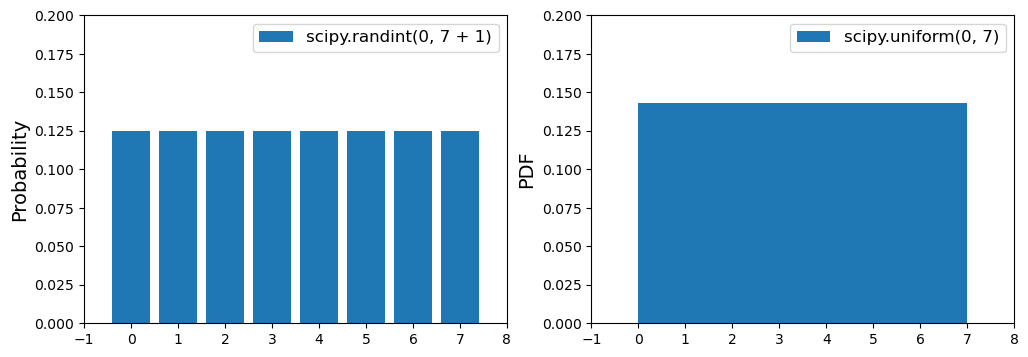

In [107]:
from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(1, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.show()

## 최적 모델 활용 및 평가

랜덤 탐색으로 확인된 최적의 모델을 활용하여 최종 평가를 진행한다.

In [108]:
final_model = rnd_search.best_estimator_  # includes preprocessing

### 테스트셋 활용

이제 더 이상의 훈련을 진행할 필요가 없을 정도로 훈련된 모델의 성능에
만족한다고 가정하자.
다음 할 일은 모델을 실전에 투입했을 때의 모델 성능 예측하기이며,
여기에 테스트셋을 활용한다.
테스트셋 또한 입력 데이터셋과 타깃셋으로 먼저 구분되어야 하고,
모델 자체에 전처리 기능이 포함되어 있음에 주의한다.

In [109]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

41422.168800999665


SciPy의 `bootstrap()` 함수를 사용하여 테스트 RMSE에 대한 
95% 신뢰구간<font size='2'>confidence interval</font>를 계산하면 다음과 같다.
신뢰구간은 줄여서 CI라 한다.

In [110]:
from scipy.stats import bootstrap

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = bootstrap([squared_errors], rmse, confidence_level=confidence,
                        random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval
print(f"95% CI for RMSE: ({rmse_lower:.4f}, {rmse_upper:.4f})")

95% CI for RMSE: (39487.5429, 43654.0546)


### 학습된 모델 기타 활용법

머신러닝 모델은 단순히 예측을 위해서만 사용되지는 않는다.
모델 종류에 따라 예측값 계산과 함께 다른 기능을 제공하기도 한다.

예를 들어, 훈련이 잘 진행된 랜덤 포레스트 모델은 
입력 데이터셋의 각 특성이 모델이 예측값을 계산할 때 얼마나 많이 기여하는가를
특성 중요도라는 기준으로 훈련 과정중에 평가한다.

캘리포니아 주택가격 예측을 위해 최적화된 랜덤 포레스트 모델은
`feature_importances_` 속성에 특성별 중요도를 저장해 두며,
확인 결과 '중위소득의 로그 변환값'(`log__median_income`) 특성의 중요도가 가장 높다.  그 다음으로는 해안 근접도 특성 중에서 특히 '내륙'(`INLAND`) 특성의 중요도가 높다.
언급된 나머지 8개 특성은 침실 비율, 가구당 방 수, 가구당 인원, 그리고 5 개의 군집 번호 등이며,
중위소득의 로그 변환값 특성의 중요도가 압도적으로 높다.

특성 중요도는 전처리 변환기와 아무 상관이 없으며, 랜덤 포레스트 모델 등 일부 모델에서만 훈련중에 함께 저장된다.

아래 코드는 `final_model`에서 랜덤 포레스트 모델의 이름이 `"random_forest"`로 지정되었기에 해당 이름을 이용하여 인덱싱을 적용한 다음에 특성 중요도가 높은 순서대로 나열한다.
예상대로 중위소득 로그값, 즉 중위소득의 중요도가 0.188 정도로 압도적으로 높게 계산되었다.

In [114]:
# 모델에 포함된 랜덤 포레스트 모델을 이용한 특성 중요도 추출
feature_importances = final_model["random_forest"].feature_importances_

# 특성 중요도와 해당 특성명을 함께 묶어서 중요도 기준으로 정렬
important_features = sorted(zip(final_model["preprocessing"].get_feature_names_out(),
                                feature_importances),
                            key=lambda x: x[1],
                            reverse=True)
important_features[:10]

[('log__median_income', np.float64(0.18836603202647126)),
 ('cat__ocean_proximity_INLAND', np.float64(0.07795960969938898)),
 ('bedrooms__ratio', np.float64(0.06110388595864347)),
 ('rooms_per_house__ratio', np.float64(0.05772194900488602)),
 ('people_per_house__ratio', np.float64(0.04569274355282605)),
 ('geo__Cluster 30 similarity', np.float64(0.041977095119231075)),
 ('geo__Cluster 9 similarity', np.float64(0.024893290428216707)),
 ('geo__Cluster 36 similarity', np.float64(0.02349145973584661)),
 ('geo__Cluster 18 similarity', np.float64(0.021384735075780065)),
 ('geo__Cluster 3 similarity', np.float64(0.019231937253583756))]

### 모델 저장

최적의 모델을 훈련시키는 과정이 매우 길 수 있다.
따라서 한 번 훈련된 좋은 모델은 파일로 저장해 놓아야 한다.
그러면 모델을 활용하고자 할 때 저장된 파일을 모델로 불러와서
훈련 없이 바로 활용할 수 있다.
또한 새롭게 훈련시킨 모델이 적절하지 않다고 판단되어
이전 버전의 모델로 되돌려야 하는 상황이 발생할 수도 있기에
잘 훈련된 모델의 저장은 필수적이다.

모델의 저장과 불러오기는 각각 `joblib` 모듈의
`dump()` 함수와 `load()` 함수를  활용한다.

- 저장하기

    ```python
    import joblib
    joblib.dump(final_model, "my_california_housing_model.pkl")
    ```
- 불러오기와 활용

    ```python
    final_model_reloaded = joblib.load("my_california_housing_model.pkl")
    final_model_reloaded.predict(X_test)
    ```

**모델 저장**

아래 코드를 실행하면 지정된 경로에 최적의 모델을 pickle 파일로 저장한다.

In [112]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

저장된 모델을 다시 불러와 바로 실전에 투입할 수 있다.
다만, 저장된 모델 활용에 필요한 라이브러리 임포트를 함께 해야 한다.
그렇지 않으면 모델 불러오고 활용할 때 필요한 클래스나 함수가 정의되지 않아 오류가 발생한다.

In [113]:
import joblib

### 중요 안내 시작 ###
# 저장된 모델 활용에 필요한 라이브러리 임포트를 함께 해야 함.
# 그렇지 않으면 모델 로드 시 필요한 클래스나 함수가 정의되지 않아 오류 발생

# from sklearn.cluster import KMeans
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.metrics.pairwise import rbf_kernel

# def column_ratio(X):
#     return X[:, [0]] / X[:, [1]]

#class ClusterSimilarity(BaseEstimator, TransformerMixin):
#    [...]
### 중요 안내 종료 ###

# 모델 불러오기
final_model_reloaded = joblib.load("my_california_housing_model.pkl")

# 새로운 데이터에 대한 예측에 활용 예제
new_data = housing.iloc[:5]  # 새로운 데이터라고 가정
predictions = final_model_reloaded.predict(new_data)
print(predictions)

[440208.11 457822.08 106671.   100105.   330637.02]
